In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

from lolcat.nn import MLP, MultiHeadGlobalAttention, LOLCAT
from lolcat.khoury_dataset import KhouryDataset, cell_type_names
from lolcat.training import train_lolcat

C:\Users\ethan\AppData\Local\miniforge3\envs\lolcat\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
subj_dates_ppc = {
    'test': [
        'bt41r 20200520',
        'bt61l 20200423',
        'bt61l 20200512',
        'bt61l 20200521',
        'bt700 20200423'
    ],
    'train': [
        'ci21l 20200930',
        'ci21l 20201005',
        'ci21l 20201027',
        'ci21l 20201118',
        'ci21l 20201124',
        'ci21l 20201208',
        'ci33l 20200930',
        'ci33l 20201005',
        'ci33l 20201007',
        'ci33l 20201027',
        'ct21l 20201208',
        'ct21l 20201209',
        'ct21l 20201216',
        'ct21l 20201218'
    ]
}

datasets = {k: KhouryDataset(subj_dates, exp_types=['spont'], region='ppc', concat=True).to('cuda') for k, subj_dates in subj_dates_ppc.items()}

filename F:\khoury_som_data\processed/bt41r 20200520,bt61l 20200423,bt61l 20200512,bt61l 20200521,bt700 20200423_ppc_spont_90samp.pt
filename F:\khoury_som_data\processed/ci21l 20200930,ci21l 20201005,ci21l 20201027,ci21l 20201118,ci21l 20201124,ci21l 20201208,ci33l 20200930,ci33l 20201005,ci33l 20201007,ci33l 20201027,ct21l 20201208,ct21l 20201209,ct21l 20201216,ct21l 20201218_ppc_spont_90samp.pt


In [3]:
# create components of LOLCAT model
encoder = MLP((-1, 32, 16, 16, 16), batchnorm=True, dropout=0.5)
pool = MultiHeadGlobalAttention(in_channels=16, out_channels=8, heads=4)
classifier = MLP((-1, 4, 2), dropout=0.5)

# as noted in the paper, initialize bias of last output layer proportional to class weights
model = LOLCAT(encoder, classifier, pool).to('cuda')

In [4]:
loss_history = train_lolcat(
    model, train_set=datasets['train'], test_set=datasets['test'], cell_type_names=cell_type_names,
    batch_size=32, weighted=True, lr=1e-2, weight_decay=1e-5, epochs=300, use_early_stopping=False,
    early_stopping_patience=25, early_stopping_patience_inc=1e-5, set_classifier_bias_from_weights=True)

Epoch 000, training: loss=0.025752, weighted  acc=0.705973, SOM+ acc=0.763359, SOM- acc=0.201093
Epoch 001, training: loss=0.022532, weighted  acc=0.700144, SOM+ acc=0.753181, SOM- acc=0.233527
Epoch 002, training: loss=0.021862, weighted  acc=0.717517, SOM+ acc=0.773537, SOM- acc=0.224650
Epoch 003, training: loss=0.021827, weighted  acc=0.584160, SOM+ acc=0.608142, SOM- acc=0.373165
Epoch 004, training: loss=0.021736, weighted  acc=0.836502, SOM+ acc=0.923664, SOM- acc=0.069648
Epoch 005, training: loss=0.021720, weighted  acc=0.850301, SOM+ acc=0.941476, SOM- acc=0.048139
Epoch 006, training: loss=0.021743, weighted  acc=0.571596, SOM+ acc=0.587786, SOM- acc=0.429157
Epoch 007, training: loss=0.021703, weighted  acc=0.897939, SOM+ acc=1.000000, SOM- acc=0.000000
Epoch 008, training: loss=0.021742, weighted  acc=0.568923, SOM+ acc=0.597964, SOM- acc=0.313418
Epoch 009, training: loss=0.021731, weighted  acc=0.669789, SOM+ acc=0.712468, SOM- acc=0.294298
Epoch 009, TEST: loss=0.690928

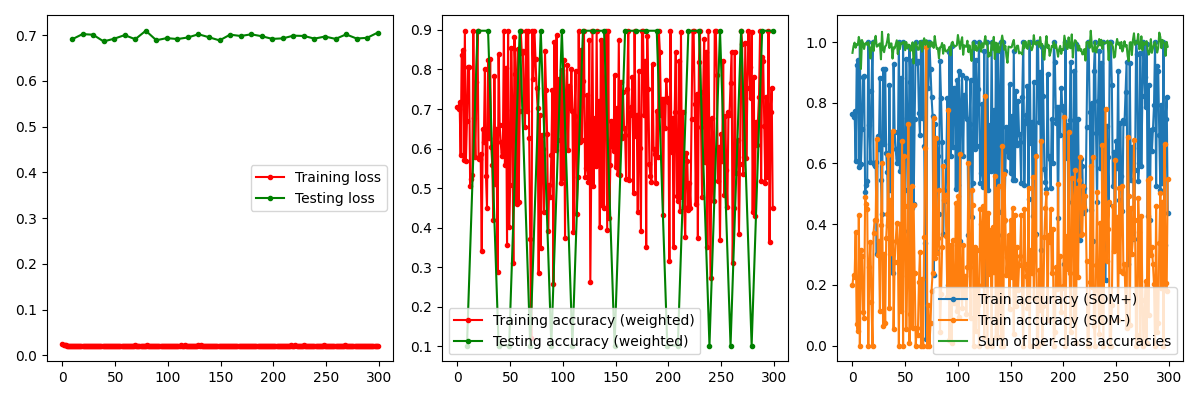

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(loss_history['train_epoch'], loss_history['train_loss'], label='Training loss', marker='.', color='r')
axs[0].plot(loss_history['test_epoch'], loss_history['test_loss'], label='Testing loss', marker='.', color='g')
axs[0].legend()

axs[1].plot(loss_history['train_epoch'], loss_history['train_acc'], label='Training accuracy (weighted)', marker='.', color='r')
axs[1].plot(loss_history['test_epoch'], loss_history['test_acc'], label='Testing accuracy (weighted)', marker='.', color='g')
axs[1].legend()

for class_name, class_acc in zip(cell_type_names, np.array(loss_history['train_acc_per_class']).T):
    axs[2].plot(loss_history['train_epoch'], class_acc, label=f'Train accuracy ({class_name})', marker='.')
axs[2].plot(loss_history['train_epoch'], np.sum(np.array(loss_history['train_acc_per_class']), axis=1), label='Sum of per-class accuracies')
axs[2].legend()

fig.tight_layout()
plt.show()